<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>
Figure 1.1.a. Jupyter environment + Python notebooks

### NDTI analyses

Some inputs from the following notebooks: https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Real_world_examples/Wetland_turbidity.html

In [1]:
from pystac_client import Client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import rasterio as rio
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import folium
import utils
from utils import load_data
# from utils import mask_and_scale
from sklearn.ensemble import RandomForestClassifier
import odc.geo.xr
import rioxarray
import matplotlib.pyplot as plt
from datetime import datetime

Define catalogue

In [2]:
catalogue = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalogue)

<font color='red'>Define your area of interest - copy and paste the bottom left latitude (min_lat) and the bottem left longitude (min_lon) and the top right latitude (max_lat) and the top right longitude (max_lon)

<font color='red'>In this activity you can use the following examples: 
  
<font color='red'>  Note we have reordered these into the wrong order so you will have to define them correctly below:</font>

In [3]:
min_lat = -18.277530
min_lon = 178.144327
max_lat = -18.252355
max_lon = 178.171476

-18.279530, 178.142327
-18.254355, 178.169476

bbox = [min_lon, min_lat, max_lon, max_lat]

<font color='red'>Define your time of interest - choose a range of a few months in 2024 using the syntax `datetime="YYYY-MM/YYYY-MM"`</font>

In [4]:
date_start = "2017-01"

In [5]:

# Get the current date and time
date_end = datetime.now()

# Format as a string (e.g., "2025-06-30")
date_end = date_end.strftime("%Y-%m")

print(date_end)

2025-07


In [6]:
datetime = date_start+'/'+date_end
print(datetime)

2017-01/2025-07


Connect to parallel computers for greater computational capacity - note you should only run this line of code once per notebook activity - do not rerun this line

In [7]:
# dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')

# configure_s3_access(cloud_defaults=True, requester_pays=True)

Search through the catalogue - define the cloud cover threshold you want. Try changing 80 to 50 here: `{"lt": 50}},` 

In [8]:
# Search through catalogue for relevant data
items = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover":{"lt": 35}},
).item_collection()

print(f"Found {len(items)} items")


Found 511 items


<font color='blue'>Load your satellite dataset based on your search parameters defined above</font>

In [9]:
# data = utils.load_data
data = load_data(items, bbox)

<font color='blue'>Set scale and masks and consider the dataset information below including the bands used for analysis:</font>

In [10]:
scaled = (data.where(data != 0) * 0.0001).clip(0, 1)

<font color='blue'>Explore the satellite image dataset you have loaded</font>

In [11]:
scaled.isel(time=0).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


/srv/conda/envs/notebook/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


#### Mask land

In [12]:
#### Mask land

mndwi = (scaled["green"]-scaled["swir16"])/(scaled["green"]+scaled["swir16"])
## Moderate land mask
# mndwi_land_mask = mndwi > 0

mndwi_land_mask = mndwi > -0.22

masked_ds = scaled.where(mndwi_land_mask)

masked_ds.isel(time=0).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


In [13]:
ndti = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

Text(0, 0.5, 'Count of pixels')

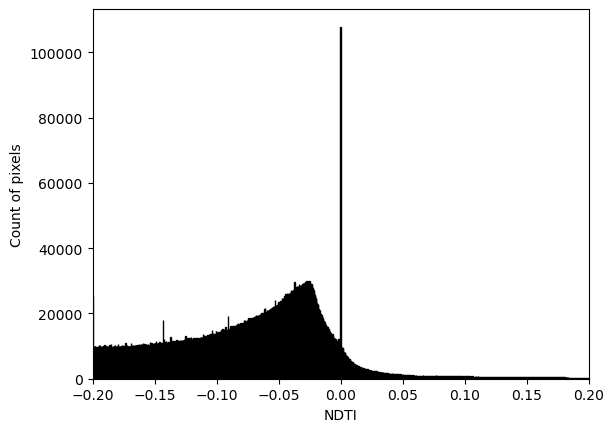

In [14]:
masked_ds["ndti"] = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

plt.hist(masked_ds.ndti.to_numpy().flatten(), color = 'blue', edgecolor = 'black',
         bins = 8000)
plt.xlim((-0.2,0.2))

# Add labels
plt.xlabel('NDTI')
plt.ylabel('Count of pixels')

In [ ]:
ndti.plot()

In [ ]:
ndti.isel(time=0).odc.explore(cmap='BrBG_r', vmin=-0.2, vmax=0.2)


In [ ]:
mean_ndti = masked_ds['ndti'].mean(dim=('x', 'y'), skipna=True)
median_ndti = masked_ds['ndti'].median(dim=('x', 'y'), skipna=True)
std_ndti = masked_ds['ndti'].std(dim=('x', 'y'), skipna=True)
max_ndti = masked_ds['ndti'].max(dim=('x', 'y'), skipna=True)

In [ ]:
var_ndti = masked_ds['ndti'].var(dim=('x', 'y'), skipna=True)
quant90_ndti = masked_ds['ndti'].quantile(0.9, dim=('x', 'y'), skipna=True)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], mean_ndti, marker='o', linestyle='-')
# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('Mean NDTI')
plt.title('Mean NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'].values, std_ndti, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Standard Deviation NDTI')
plt.title('Standard Deviation NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'].values, median_ndti, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Median NDTI')
plt.title('Median NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], var_ndti, marker='o', linestyle='-')

# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('Variance in NDTI')
plt.title('Variance NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], quant90_ndti, marker='o', linestyle='-')

# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('0.9 - Quantile in NDTI')
plt.title('0.9 - Quantile NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

plt.figure(figsize=(12,6))
plt.plot(time, mean_ndti, label='Mean NDTI')
plt.plot(time, max_ndti, label='Max NDTI')
plt.plot(time, std_ndti, label='Std NDTI')
plt.plot(time, var_ndti, label='Variance in NDTI')
plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

plt.xlabel('Date')
plt.ylabel('NDTI')
plt.title('NDTI Statistics Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

plt.figure(figsize=(12,6))
plt.plot(time, std_ndti, label='Std NDTI')
plt.plot(time, var_ndti, label='Variance in NDTI')
plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

plt.xlabel('Date')
plt.ylabel('NDTI')
plt.title('NDTI Statistics Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

plt.figure(figsize=(12,6))
plt.plot(time, std_ndti, label='Std NDTI')
plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

plt.xlabel('Date')
plt.ylabel('NDTI')
plt.title('NDTI Statistics Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

plt.figure(figsize=(12,6))
plt.plot(time, std_ndti, label='Std NDTI')

plt.xlabel('Date')
plt.ylabel('NDTI')
plt.title('NDTI Statistics Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Compute the standard deviation of NDTI over time for each pixel


In [ ]:
std_ndti = masked_ds['ndti'].std(dim='time', skipna=True)


Mask (set to NaN or another value) those pixels where this std exceeds your threshold


In [ ]:
threshold = 0.04
thresholds = [0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08]
mask_std_ndti = std_ndti > threshold
masked_ds = masked_ds.where(~mask_std_ndti)

In [ ]:
plt.imshow(masked_ds['ndti'].isel(time=0), cmap='gray')
plt.title('Masked NDTI overlayed over image 1')
plt.show()

In [ ]:
plt.imshow(masked_ds['ndti'].mean(dim='time'), cmap='gray')
plt.title('Mean Masked NDTI overlayed over mean image')
plt.show()

In [ ]:
n = len(thresholds)

fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(4*n, 4))

for i, thresh in enumerate(thresholds):
    mask = std_ndti > thresh  # std_ndti is 2D (y, x)
    ax = axes[i]
    im = ax.imshow(mask, cmap='gray')
    ax.set_title(f'Threshold: {thresh}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

threshold_a = 0.03
threshold_b = 0.04

mask_a = std_ndti > threshold_a  # std_ndti is 2D
mask_b = std_ndti > threshold_b

# Combine masks: 0 = below both, 1 = above A only, 2 = above both
combined = np.zeros(std_ndti.shape, dtype=int)
combined[mask_a] = 1
combined[mask_b] = 2

# Custom colormap: 0=white, 1=red, 2=blue (adjust as you wish)
cmap = ListedColormap(['white', 'red', 'blue'])

plt.imshow(combined, cmap=cmap)
plt.title(f'Mask: Red=std>{threshold_a}, Blue=std>{threshold_b}')
plt.axis('off')
plt.show()